In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 331s 2us/step


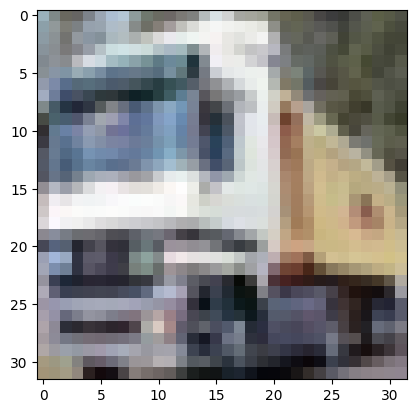

In [3]:
import matplotlib.pyplot as plt
plt.imshow(train_images[1])

In [4]:
train_labels

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], shape=(50000, 1), dtype=uint8)

In [5]:
train_filter = (train_labels == 3) | (train_labels == 5)
test_filter  = (test_labels == 3) | (test_labels == 5)

In [6]:
train_filter

array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]], shape=(50000, 1))

In [7]:
X_train = train_images[train_filter.flatten()]
y_train = train_labels[train_filter.flatten()]
X_test  = test_images[test_filter.flatten()]
y_test  = test_labels[test_filter.flatten()]

In [8]:
y_train = (y_train == 5).astype(int)
y_test  = (y_test == 5).astype(int)

In [9]:
X_train = X_train / 255.0
X_test  = X_test / 255.0

In [10]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')   # Binary output
])

C:\Users\shriy\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [12]:
model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.5573 - loss: 0.6825 - val_accuracy: 0.6410 - val_loss: 0.6530
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.6489 - loss: 0.6272 - val_accuracy: 0.6870 - val_loss: 0.5926
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7044 - loss: 0.5687 - val_accuracy: 0.7430 - val_loss: 0.5430
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7377 - loss: 0.5298 - val_accuracy: 0.7090 - val_loss: 0.5525
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.7618 - loss: 0.4962 - val_accuracy: 0.7450 - val_loss: 0.5110
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7854 - loss: 0.4542 - val_accuracy: 0.7690 - val_loss: 0.4824
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.8101 - loss: 0.4168 - val_accuracy: 0.7750 - val_loss: 0.4800
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8324 - loss: 0.3780 - val_accu

In [13]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7615 - loss: 0.5455
Test Accuracy: 0.7615000009536743


In [14]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context